Green Skill Dataset Analysis using Pandas and Seaborn

A sustainability dataset contains information related to renewable energy, carbon emissions, electricity production, and environmental indicators. It helps analyze environmental trends and supports sustainable development.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

Import Dataset

The read_csv() function is used to import the dataset into Python.

In [3]:
df = pd.read_csv("owid-energy-data.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


1. head()

The head() method displays the first five rows of the dataset.

In [4]:
print(df.head())

# Analysis:
# Displays the first records of the dataset.
# Helps understand the structure of the data.

         country  year iso_code  population  gdp  biofuel_cons_change_pct  \
0  ASEAN (Ember)  2000      NaN         NaN  NaN                      NaN   
1  ASEAN (Ember)  2001      NaN         NaN  NaN                      NaN   
2  ASEAN (Ember)  2002      NaN         NaN  NaN                      NaN   
3  ASEAN (Ember)  2003      NaN         NaN  NaN                      NaN   
4  ASEAN (Ember)  2004      NaN         NaN  NaN                      NaN   

   biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
0                      NaN                      NaN                  NaN   
1                      NaN                      NaN                  NaN   
2                      NaN                      NaN                  NaN   
3                      NaN                      NaN                  NaN   
4                      NaN                      NaN                  NaN   

   biofuel_elec_per_capita  ...  solar_share_elec  solar_share_energy  \
0      

2. shape

The shape attribute returns the total number of rows and columns.

In [5]:
print(df.shape)

# Analysis:
# Shows the size of the dataset.

(23377, 130)


3. columns

The columns attribute returns all feature names.

In [6]:
print(df.columns)

# Analysis:
# Every column represents a different environmental indicator.

Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'biofuel_cons_change_pct', 'biofuel_cons_change_twh',
       'biofuel_cons_per_capita', 'biofuel_consumption',
       'biofuel_elec_per_capita',
       ...
       'solar_share_elec', 'solar_share_energy', 'wind_cons_change_pct',
       'wind_cons_change_twh', 'wind_consumption', 'wind_elec_per_capita',
       'wind_electricity', 'wind_energy_per_capita', 'wind_share_elec',
       'wind_share_energy'],
      dtype='str', length=130)


4. info()

The info() method displays the data type and missing values.

In [7]:
df.info()

# Analysis:
# Helps identify numerical and categorical columns.

<class 'pandas.DataFrame'>
RangeIndex: 23377 entries, 0 to 23376
Columns: 130 entries, country to wind_share_energy
dtypes: float64(127), int64(1), str(2)
memory usage: 23.2 MB


5. describe()

The describe() method gives statistical information about numerical columns.

In [8]:
print(df.describe())

# Analysis:
# Shows mean, minimum, maximum and quartiles.

               year    population           gdp  biofuel_cons_change_pct  \
count  23377.000000  1.889400e+04  1.178000e+04              2070.000000   
mean    1976.238611  1.058587e+08  4.257565e+11                43.478804   
std       35.331092  4.720948e+08  3.507870e+12               286.672317   
min     1900.000000  1.776000e+03  1.642060e+08              -100.000000   
25%     1949.000000  1.599088e+06  1.426394e+10                -0.968000   
50%     1985.000000  6.951653e+06  4.357680e+10                 6.695500   
75%     2005.000000  2.581793e+07  1.830576e+11                23.320750   
max     2025.000000  8.231613e+09  1.301126e+14              6373.062000   

       biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
count              7903.000000              6338.000000          8057.000000   
mean                  1.054261                55.157113            15.092054   
std                   6.641947               180.660550            75.94252

6. Handle Null Values

Missing values are replaced with the mean of numerical columns.

In [ ]:
numeric_columns = df.select_dtypes(include="number").columns

df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

print(df.isnull().sum())
# Mean is suitable for numerical data and avoids losing rows.

country                      0
year                         0
iso_code                  6112
population                   0
gdp                          0
                          ... 
wind_elec_per_capita         0
wind_electricity             0
wind_energy_per_capita       0
wind_share_elec              0
wind_share_energy            0
Length: 130, dtype: int64


7. Feature Engineering

Feature engineering creates new useful columns from existing data.

In [10]:
# Create Energy Per Capita Feature

df["Energy_per_Capita"] = df["primary_energy_consumption"] / df["population"]

print(df[["country","Energy_per_Capita"]].head())

# It measures average energy consumption per person.

         country  Energy_per_Capita
0  ASEAN (Ember)            0.00004
1  ASEAN (Ember)            0.00004
2  ASEAN (Ember)            0.00004
3  ASEAN (Ember)            0.00004
4  ASEAN (Ember)            0.00004


C:\Users\jayvi\AppData\Local\Temp\ipykernel_15808\1076839775.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["Energy_per_Capita"] = df["primary_energy_consumption"] / df["population"]


8. Label Encoding

Label Encoding converts categorical values into numbers.

In [11]:
encoder = LabelEncoder()

df["country"] = encoder.fit_transform(df["country"])

print(df["country"].head())

# Why?
# Machine learning models require numerical values.

0    0
1    0
2    0
3    0
4    0
Name: country, dtype: int32


9. Scaling

StandardScaler scales numerical columns to a common range.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[["population","gdp"]] = scaler.fit_transform(
    df[["population","gdp"]]
)

print(df[["population","gdp"]].head())

     population  gdp
0 -3.511032e-17  0.0
1 -3.511032e-17  0.0
2 -3.511032e-17  0.0
3 -3.511032e-17  0.0
4 -3.511032e-17  0.0


10. Histogram

A histogram shows the distribution of a numerical column

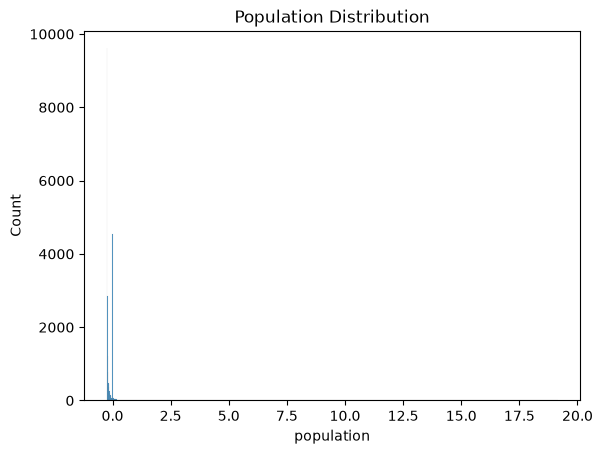

In [13]:
sns.histplot(df["population"])

plt.title("Population Distribution")

plt.show()

11. Scatter Plot

A scatter plot shows the relationship between two numerical columns.

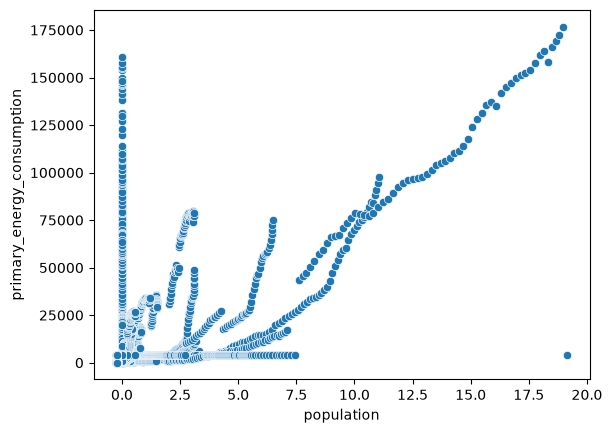

In [14]:
sns.scatterplot(
    x="population",
    y="primary_energy_consumption",
    data=df
)

plt.show()

12. Box Plot

A box plot is used to detect outliers.

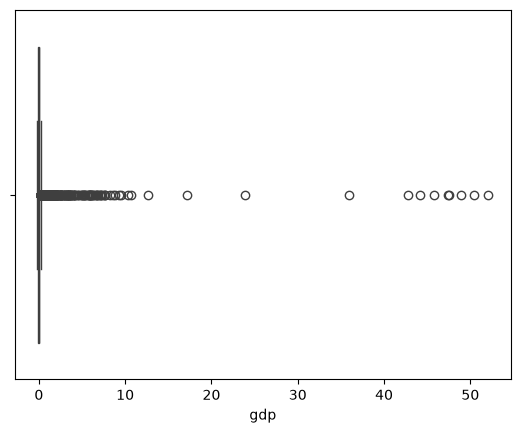

In [15]:
sns.boxplot(x=df["gdp"])

plt.show()

# Some countries have unusually high GDP values,
# which appear as outliers.

Generalisation

Generalisation explains the purpose of important columns.

In [17]:
# Country
# Name of the country.

# Year
# Year of data collection.

# Population
# Total population.

# GDP
# Economic growth.

# Primary Energy Consumption
# Total energy consumed.

# Renewable Energy
# Clean energy production.

# CO2 Emissions
# Carbon dioxide released into the atmosphere.

Relationship Between Features

Different features influence each other.

In [18]:
# Population ↑ → Energy Consumption ↑

# GDP ↑ → Energy Consumption ↑

# Renewable Energy ↑ → CO2 Emissions ↓

# Countries with higher GDP generally
# consume more energy.

# Renewable energy helps reduce
# dependence on fossil fuels.

Insights

1. The dataset contains renewable energy information.

2. Missing values were handled using the mean.

3. Feature engineering created a new useful feature.

4. Label Encoding converted categorical data into numbers.

5. StandardScaler normalized numerical columns.

6. Seaborn graphs helped visualize the dataset.

7. Population is positively related to energy consumption.

8. Renewable energy supports sustainability.